# 2025-06-24 - Sprint network properties

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
plt.rcParams['svg.fonttype'] = 'none'


## Writing down the network

In [2]:
motus_df = pd.read_csv("../results/2025-06-13.sprint/base.motus-hits.csv", sep=';')
motus_df_host_species = motus_df.value_counts(
    ['Host_taxon', 'species']
).reset_index()
motus_df_host_species

,Host_taxon,species,count
0,Convolvulus arvensis,uncultured Clostridium sp.,14
1,Diplotaxis erucoides,uncultured Clostridium sp.,10
2,Cucumis melo,uncultured Clostridium sp.,9
3,Cucumis melo,Janthinobacterium sp. B9-8,8
4,Carduus bourgeanus,uncultured Clostridium sp.,7
...,...,...,...
1235,Conyza bonariensis,Cellulomonas massiliensis,1
1236,Conyza bonariensis,Caulobacter sp. URHA0033,1
1237,Conyza bonariensis,Brevundimonas vesicularis,1
1238,Conyza bonariensis,Brevundimonas nasdae,1


In [3]:
G = nx.Graph()
for _, row in motus_df_host_species.iterrows():

    G.add_node(row.Host_taxon, role='Host')
    G.add_node(row.species, role='Bacteria')
    G.add_edge(row.species, row.Host_taxon, weight=row['count'])

nx.write_gml(G, "../results/2025-06-13.sprint/networks/intdata.bacteria-host.Full.gml")

In [4]:
motus_df.value_counts(
    ['Host_taxon', 'species']
).reset_index().pivot(
    index='Host_taxon', columns='species', 
    values='count'
).fillna(0.0).to_csv(
    "../results/2025-06-13.sprint/intdata.adj-mat.full.host-bacteria.csv", sep=';')

## Network

In [5]:
null = pd.read_csv("../results/2025-06-13.sprint/network-properties/intdata.Full.host-bacteria.null.csv")
observed = pd.read_csv("../results/2025-06-13.sprint/network-properties/intdata.Full.host-bacteria.observed.csv")

In [6]:
null

,connectance,modularity Q,NODF
0,0.020282,0.401871,10.040903
1,0.020096,0.411660,9.673285
2,0.020468,0.398365,9.779165
3,0.020164,0.399318,9.186734
4,0.020231,0.396452,9.595789
...,...,...,...
995,0.020299,0.396795,9.427518
996,0.020282,0.395637,9.978673
997,0.020502,0.395481,10.256415
998,0.020383,0.398601,9.778189


In [7]:
observed

,Metric,Value
0,connectance,0.020958
1,modularity Q,0.430889
2,NODF,14.490056
3,ElapsedTime,14299.673000


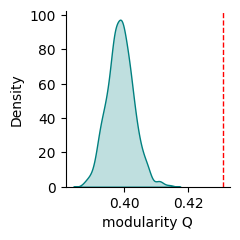

In [8]:
g = sns.displot(data=null, x='modularity Q', kind='kde', fill=True, height=2.5, color='teal')
g.axes[0, 0].axvline(observed.set_index('Metric').loc['modularity Q']['Value'], color='red', linewidth=1.0, linestyle='--')
g.savefig("../figures/draft0-figures/Fig3B.00.svg")

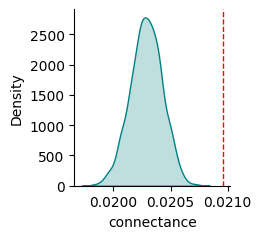

In [9]:
g = sns.displot(data=null, x='connectance', kind='kde', fill=True, height=2.5, color='teal')
g.axes[0, 0].axvline(observed.set_index('Metric').loc['connectance']['Value'], color='red', linewidth=1.0, linestyle='--')
g.savefig("../figures/draft0-figures/Fig3B.01.svg")

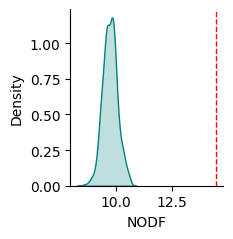

In [10]:
g = sns.displot(data=null, x='NODF', kind='kde', fill=True, height=2.5, color='teal')
g.axes[0, 0].axvline(observed.set_index('Metric').loc['NODF']['Value'], color='red', linewidth=1.0, linestyle='--')
g.savefig("../figures/draft0-figures/Fig3B.02.svg")

In [11]:
null_mean = null.mean().reset_index()
null_std = null.std().reset_index()
null_statistics = pd.merge(null_mean, null_std, on='index')
null_statistics.columns = ['index', 'mean', 'std']
null_statistics

,index,mean,std
0,connectance,0.020286,0.000139
1,modularity Q,0.398638,0.004203
2,NODF,9.720201,0.331233


In [12]:
Z = pd.merge(observed, null_statistics, left_on='Metric', right_on='index').drop(columns=['index'])
Z['z-score'] = (Z['Value'] - Z['mean']) / Z['std']
Z

,Metric,Value,mean,std,z-score
0,connectance,0.020958,0.020286,0.000139,4.820510
1,modularity Q,0.430889,0.398638,0.004203,7.673075
2,NODF,14.490056,9.720201,0.331233,14.400318


In [13]:
Z

,Metric,Value,mean,std,z-score
0,connectance,0.020958,0.020286,0.000139,4.820510
1,modularity Q,0.430889,0.398638,0.004203,7.673075
2,NODF,14.490056,9.720201,0.331233,14.400318


In [14]:
def read_network_results(null_path, observations_path, label):
    print(label)
    null = pd.read_csv(null_path)
    observed = pd.read_csv(observations_path)
    null_mean = null.mean().reset_index()
    null_std = null.std().reset_index()
    null_statistics = pd.merge(null_mean, null_std, on='index')
    null_statistics.columns = ['index', 'mean', 'std']
    Z = pd.merge(observed, null_statistics, left_on='Metric', right_on='index').drop(columns=['index'])
    Z['z-score'] = (Z['Value'] - Z['mean']) / Z['std']
    Z['label'] = label
    return Z[['label', 'Metric', 'Value', 'mean', 'std', 'z-score']]

In [16]:

full_properties = pd.concat([read_network_results(
    f"../results/2025-06-13.sprint/network-properties/intdata.{label:s}.host-bacteria.null.csv",
    f"../results/2025-06-13.sprint/network-properties/intdata.{label:s}.host-bacteria.observed.csv",
    label
) for label in ['Full', 'Crop', 'Edge', 'Wasteland', 'Oak']])
full_properties

Full
Crop
Edge
Wasteland
Oak


,label,Metric,Value,mean,std,z-score
0,Full,connectance,0.020958,0.020286,0.000139,4.820510
1,Full,modularity Q,0.430889,0.398638,0.004203,7.673075
2,Full,NODF,14.490056,9.720201,0.331233,14.400318
0,Crop,connectance,0.050235,0.048415,0.000730,2.491765
1,Crop,modularity Q,0.580203,0.535341,0.009344,4.801314
2,Crop,NODF,15.895033,12.682205,1.049426,3.061509
0,Edge,connectance,0.038366,0.035984,0.000384,6.200880
1,Edge,modularity Q,0.479024,0.461624,0.006787,2.563532
2,Edge,NODF,19.637742,12.543033,0.568322,12.483606
0,Wasteland,connectance,0.036574,0.033002,0.000446,8.000912


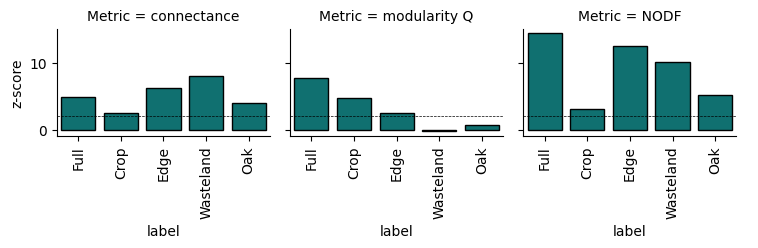

In [38]:
g = sns.catplot(x='label', y='z-score', data=full_properties, kind='bar', col='Metric', height=2.0, aspect=1.25, color='teal', edgecolor='black')
g.axes[0, 0].axhline(2.0, color='black', linestyle='--', linewidth=0.5)
g.axes[0, 1].axhline(2.0, color='black', linestyle='--', linewidth=0.5)
g.axes[0, 2].axhline(2.0, color='black', linestyle='--', linewidth=0.5)
g.set_xticklabels(rotation=90)
g.savefig("../figures/draft0-figures/Fig3C.00.svg")